# Étape 1 : Prendre en main le pipeline existant

## 1.1 Exécuter pipeline_v1.py de bout en bout sur les données fournies.

In [1]:
# -*- coding: utf-8 -*-
"""
pipeline_v1.py — Préparation des données pour le scoring crédit Finova
Auteur : K. Moreau (équipe Data, 2024)

Prépare les dossiers de crédit pour l'entraînement du modèle de scoring :
nettoyage, encodage, normalisation, découpage train/test.

Usage : python pipeline_v1.py [chemin_vers_finova_credits.db]
"""

import sys
import sqlite3

import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

DB_PATH = sys.argv[1] if len(sys.argv) > 1 else "finova_credits.db"
DB_PATH = "finova_credits.db"

# colonnes inutiles pour le scoring
COLONNES_INUTILES = ["nom", "prenom", "email", "telephone_mobile", "adresse",
                     "ville", "iban", "num_secu", "date_naissance"]


def load_data():
    """Charge les dossiers de crédit depuis la base."""
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("SELECT * FROM dossiers_credit", conn)
    conn.close()
    df = df.drop(columns=COLONNES_INUTILES)
    return df


def fix_amounts(df):
    """Corrige la colonne montant_credit et complète les montants manquants."""
    df["montant_credit"] = pd.to_numeric(df["montant_credit"], errors="coerce")
    df["montant_credit"] = df["montant_credit"].fillna(df["montant_credit"].mean())
    return df


def clean_data(df):
    """Supprime les enregistrements invalides."""
    df = df.dropna()
    return df.reset_index(drop=True)


def encode_features(df):
    """Encode les variables catégorielles en numérique."""
    # le numéro client encode l'ancienneté de la relation, on le conserve
    df["numero_client"] = df["numero_client"].str.replace("FIN-", "").astype(int)
    df["code_postal"] = pd.to_numeric(df["code_postal"], errors="coerce").fillna(0).astype(int)

    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "str":
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    return df


def prepare_datasets(df):
    """Normalise les données et construit les jeux d'entraînement et de test."""
    X = df.drop(columns=["defaut"])
    y = df["defaut"]

    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    return X_train, X_test, y_train, y_test


def main():
    df = load_data()
    print(f"Dossiers chargés : {len(df)}")

    df = fix_amounts(df)
    df = clean_data(df)
    print(f"Dossiers après nettoyage : {len(df)}")

    df = encode_features(df)
    X_train, X_test, y_train, y_test = prepare_datasets(df)
    print(f"Train : {len(X_train)} | Test : {len(X_test)}")

    # entraînement rapide pour valider le pipeline
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Accuracy du modèle de contrôle : {acc:.3f}")

    X_train.assign(defaut=y_train.values).to_csv("train.csv", index=False)
    X_test.assign(defaut=y_test.values).to_csv("test.csv", index=False)
    print("Jeux de données exportés : train.csv, test.csv")


if __name__ == "__main__":
    main()


Dossiers chargés : 1025
Dossiers après nettoyage : 897
Train : 717 | Test : 180
Accuracy du modèle de contrôle : 0.728
Jeux de données exportés : train.csv, test.csv


## 1.2 Documenter chaque traitement appliqué : ce que le code fait réellement, pas ce que les noms de fonctions prétendent
### et
## 1.3 Lister les choix qui vous semblent discutables, avec pour chacun une hypothèse sur son impact.

## `load_data()`

**Ce que fait la fonction :**
- Ouvre une connexion SQLite vers `finova_credits.db`
- Charge toute la table `dossiers_credit` dans un DataFrame
- Ferme la connexion
- Supprime les colonnes personnelles sans valeur prédictive (nom, IBAN, num_secu, etc.)

**Choix discutable :**
- `numero_client` est conservé comme feature au motif qu'il encoderait 
  l'ancienneté client — ce lien n'est pas vérifié dans les données. En production, devrait être exclu ou remplacé par 
  une vraie variable métier d'ancienneté si disponible.

In [3]:
def load_data():
    """Charge les dossiers de crédit depuis la base."""
    conn = sqlite3.connect(DB_PATH)
    df = pd.read_sql("SELECT * FROM dossiers_credit", conn)
    conn.close()
    df = df.drop(columns=COLONNES_INUTILES)
    return df

## `fix_amounts()`

**Ce que fait la fonction :**
- Convertit `montant_credit` en numérique — les valeurs non convertibles 
  (ex: "2 442 EUR") deviennent NaN silencieusement
- Remplace les NaN par la moyenne de la colonne

**Choix discutables :**
- Les valeurs comme "2 442 EUR" sont récupérables avec un nettoyage 
  de texte simple (strip EUR, espaces) — les perdre est inutile
- Imputer par la moyenne fausse la distribution et peut impacter 
  le scoring, surtout pour une variable aussi importante que le montant
- Imputation par la **moyenne** calculée sur tout le dataset avant le split 
  cause une fuite d'information légère vers le jeu de test.
  
  Solution : calculer la médiane uniquement sur le jeu d'entraînement 
  après le split, et l'appliquer ensuite sur le jeu de test.

In [4]:
def fix_amounts(df):
    """Corrige la colonne montant_credit et complète les montants manquants."""
    df["montant_credit"] = pd.to_numeric(df["montant_credit"], errors="coerce")
    df["montant_credit"] = df["montant_credit"].fillna(df["montant_credit"].mean())
    return df

## `clean_data()`

**Ce que fait la fonction :**
- Supprime toutes les lignes contenant au moins un NaN
- Réinitialise l'index

**Résultat : 128 dossiers perdus (1025 → 897)**

Les NaN concernent uniquement deux colonnes :
- `epargne` : 81 valeurs manquantes
- `anciennete_emploi` : 51 valeurs manquantes

**Choix discutable :**
- Le commentaire dit "enregistrements invalides" mais une valeur manquante 
  n'est pas une invalide — elle peut être simplement non renseignée
- L'absence d'épargne ou d'ancienneté d'emploi est elle-même une information 
  utile pour le scoring : supprimer ces dossiers efface potentiellement 
  les profils les plus risqués
- Une imputation adaptée aurait permis de conserver ces 128 dossiers

In [5]:
def clean_data(df):
    """Supprime les enregistrements invalides."""
    df = df.dropna()
    return df.reset_index(drop=True)

## `encode_features()`

**Ce que fait la fonction :**
- Supprime le préfixe "FIN-" de `numero_client` et le convertit en entier
- Convertit `code_postal` en numérique, remplace les erreurs par 0
- Parcourt toutes les colonnes catégorielles (type `object` ou `str`) 
  et les encode en nombres entiers avec `LabelEncoder`

**Ce que fait `LabelEncoder` :**
Il assigne un nombre entier à chaque catégorie selon l'ordre alphabétique.
Par exemple pour `historique_credit` :
- `"aucun crédit"` → 0
- `"crédits soldés"` → 1  
- `"retards de paiement"` → 2

**Choix discutables :**
- `LabelEncoder` assigne un ordre arbitraire (alphabétique) que le modèle 
  va interpréter comme un ordre numérique réel — ce qui ne correspond pas au contexte métier réel
- Pour les colonnes avec un ordre naturel de risque (ex: `historique_credit`, 
  `epargne`) → il faudrait un encodage ordinal défini manuellement
- Pour les colonnes sans ordre naturel (ex: `objet_credit`, `logement`) 
  → il faudrait un One-Hot Encoding

In [6]:
def encode_features(df):
    """Encode les variables catégorielles en numérique."""
    # le numéro client encode l'ancienneté de la relation, on le conserve
    df["numero_client"] = df["numero_client"].str.replace("FIN-", "").astype(int)
    df["code_postal"] = pd.to_numeric(df["code_postal"], errors="coerce").fillna(0).astype(int)

    for col in df.columns:
        if df[col].dtype == object or str(df[col].dtype) == "str":
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    return df

## `prepare_datasets()`

**Ce que fait la fonction :**
- Sépare les features (`X`) de la variable cible `defaut` (`y`)
- Normalise toutes les features avec `StandardScaler` :
  soustrait la moyenne et divise par l'écart-type pour centrer 
  les valeurs autour de zéro avec une variance de 1
- Découpe les données en jeu d'entraînement (80%) et de test (20%)

**Choix discutables :**

1. **Data leakage** — c'est le défaut le plus grave.
   Le `StandardScaler` est fitté sur toutes les données AVANT le split.
   La moyenne et l'écart-type sont donc calculés en incluant le jeu de test,
   ce qui donne au modèle une connaissance indirecte des données de test.
   Cela explique les scores "anormalement optimistes" constatés.
   
   Solution correcte :
```python
   X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
   scaler.fit_transform(X_train)  # fit uniquement sur le train
   scaler.transform(X_test)       # transform seulement sur le test
```

2. **Absence de `random_state`**
   Le découpage est différent à chaque exécution — les résultats ne sont pas reproductibles. Ce qui explique ce problème du brief "Le data scientist de l'équipe, qui consomme la sortie de ce pipeline, constate des résultats instables : des modèles dont la performance varie fortement d'un réentraînement à l'autre"

   Solution :
    `train_test_split(X, y, test_size=0.2, random_state=42)`
3. **Split non stratifié**
   Le dataset est déséquilibré (70% non-défaut / 30% défaut). Sans 
   `stratify=y`, le split peut produire des proportions différentes 
   entre train et test, rendant l'évaluation moins fiable.

   Solution : `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)`

In [7]:
def prepare_datasets(df):
    """Normalise les données et construit les jeux d'entraînement et de test."""
    X = df.drop(columns=["defaut"])
    y = df["defaut"]

    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    return X_train, X_test, y_train, y_test

## `main()`

**Ce que fait la fonction :**
- Orchestre l'ensemble du pipeline en appelant les fonctions dans l'ordre :
  1. Chargement des données (`load_data`)
  2. Correction des montants (`fix_amounts`)
  3. Nettoyage des NaN (`clean_data`)
  4. Encodage des variables catégorielles (`encode_features`)
  5. Création des jeux train/test (`prepare_datasets`)
- Entraîne une régression logistique pour valider le pipeline
- Exporte les jeux train/test en CSV

**Choix discutables :**

1. **Métrique de validation insuffisante**
   L'accuracy seule ne suffit pas pour un scoring crédit.
   Le dataset est déséquilibré (70% non-défaut / 30% défaut) — un modèle 
   qui prédit "pas de défaut" pour tout le monde obtiendrait 70% d'accuracy 
   sans aucune utilité.
   
   Il faudrait au minimum :
   - Un `classification_report` avec F1 macro et weighted
   - Le **recall** sur la classe "défaut" — métrique la plus critique 
     pour une banque : parmi tous les vrais défauts, combien le modèle 
     en a-t-il détectés ?

2. **Ordre des opérations**
   Les défauts identifiés dans les fonctions précédentes (data leakage, 
   dropna trop agressif, LabelEncoder) se cumulent ici et expliquent 
   les résultats instables observés par le data scientist.

In [8]:
def main():
    df = load_data()
    print(f"Dossiers chargés : {len(df)}")

    df = fix_amounts(df)
    df = clean_data(df)
    print(f"Dossiers après nettoyage : {len(df)}")

    df = encode_features(df)
    X_train, X_test, y_train, y_test = prepare_datasets(df)
    print(f"Train : {len(X_train)} | Test : {len(X_test)}")

    # entraînement rapide pour valider le pipeline
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"Accuracy du modèle de contrôle : {acc:.3f}")

    X_train.assign(defaut=y_train.values).to_csv("train.csv", index=False)
    X_test.assign(defaut=y_test.values).to_csv("test.csv", index=False)
    print("Jeux de données exportés : train.csv, test.csv")

# Etape 2 : Auditer la qualité des données sources

### Valeurs manquantes

Deux colonnes présentent des valeurs manquantes :

| Colonne | Manquants | Proportion |
|---------|-----------|------------|
| `epargne` | 81 | 7.9% |
| `anciennete_emploi` | 51 | 5.0% |

Ces colonnes ne sont pas obligatoires — leur absence ne rend pas un dossier invalide. 
Le pipeline les supprime via `dropna()`, ce qui entraîne la perte de 128 dossiers (12.5% du dataset).

In [9]:
df = load_data()
df = fix_amounts(df)
missing = pd.DataFrame({
    'manquants': df.isnull().sum(),
    'pourcentage': (df.isnull().sum() / len(df) * 100).round(1)
})
missing['pourcentage'] = missing['pourcentage'].astype(str) + '%'
print(missing[missing['manquants'] > 0])

                   manquants pourcentage
epargne                   81        7.9%
anciennete_emploi         51        5.0%


### Détection des doublons

#### Doublons exacts
18 doublons exacts détectés, soit 1.8% du dataset.
Ces dossiers sont identiques sur toutes les colonnes.

In [10]:
print(f"Doublons : {df.duplicated().sum()} ({(df.duplicated().sum() / len(df) * 100).round(1)}%)")

Doublons : 18 (1.8%)


In [11]:
cols = ['age', 'sexe', 'code_postal', 'montant_credit', 'duree_credit_mois']
print(df.duplicated(subset=cols).sum())

25


In [12]:
conn = sqlite3.connect(DB_PATH)
df_raw = pd.read_sql("SELECT * FROM dossiers_credit", conn)
conn.close()
print(df_raw.duplicated(subset=['num_secu']).sum())

25


#### Doublons masqués
25 doublons masqués détectés via deux méthodes croisées :

**Méthode 1** — Combinaison de colonnes clés :
`age`, `sexe`, `code_postal`, `montant_credit`, `duree_credit_mois`

**Méthode 2** — Numéro de sécurité sociale (`num_secu`) :
Chargement des données brutes avant suppression des colonnes personnelles,
puis détection des `num_secu` en double.

Les deux méthodes donnent le même résultat : **25 doublons masqués**.
Ces dossiers partagent le même profil client mais ont des `numero_client` différents.

Les 18 doublons exacts sont inclus dans ces 25 — il y a donc
**7 doublons masqués supplémentaires** non détectables par une 
déduplication naïve.

> ⚠️ Note : `num_secu` est supprimé dès le début du pipeline dans 
> `load_data()`, ce qui empêche cette détection en production. 
> L'audit qualité devrait être effectué avant la suppression 
> des colonnes d'identification.

#### Valeurs aberrantes

### Valeurs aberrantes

Détectées via `df.describe()` et filtres métier :

| Colonne | Condition | Nb lignes | Règle métier |
|---------|-----------|-----------|--------------|
| `age` | < 18 ans | 4 | Âge légal minimum pour un crédit conso |
| `age` | > 100 ans | 2 | Âge biologiquement improbable |
| `montant_credit` | < 0 | 3 | Un montant négatif est impossible |
| `duree_credit_mois` | > 120 mois | 3 | Crédit conso limité à 10 ans maximum |
| `nb_personnes_charge` | < 0 | 2 | Nombre de personnes négatif impossible |

**Total : 14 enregistrements aberrants** (1.4% du dataset)

> ⚠️ Le pipeline actuel ne détecte ni ne corrige aucune de ces anomalies.

In [13]:
df.describe()

,duree_credit_mois,montant_credit,taux_effort,anciennete_logement,age,nb_credits_existants,nb_personnes_charge,defaut
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,23.748293,3263.057143,2.967805,2.846829,35.675122,1.403902,1.149268,0.300488
std,54.214157,2740.661491,1.116258,1.102621,12.201067,0.575191,0.372599,0.458694
min,4.000000,-3031.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,12.000000,1386.000000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2406.000000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3914.000000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,999.000000,15945.000000,4.000000,4.000000,123.000000,4.000000,2.000000,1.000000


In [14]:
print("age < 18 :", len(df[df['age'] < 18]))
print("montant_credit < 0 :", len(df[df['montant_credit'] < 0]))
print("duree_credit_mois > 120 :", len(df[df['duree_credit_mois'] > 120]))
print("nb_personnes_charge < 0 :", len(df[df['nb_personnes_charge'] < 0]))
print("age > 100 :", len(df[df['age'] > 100]))

age < 18 : 4
montant_credit < 0 : 3
duree_credit_mois > 120 : 3
nb_personnes_charge < 0 : 2
age > 100 : 2


### Incohérences de format et de valeurs

#### 1. `travailleur_etranger` — variantes de casse et espaces
5 variantes détectées pour 2 valeurs attendues :

| Valeur brute | Valeur correcte |
|--------------|-----------------|
| `'oui'` | oui |
| `'Oui '` | oui |
| `'OUI'` | oui |
| `'non'` | non |
| `' non'` | non |

Le `LabelEncoder` va traiter ces 5 variantes comme 5 catégories distinctes,
introduisant du bruit dans le modèle.

#### 2. `epargne` — ambiguïté entre NaN et "pas d'épargne connue"
La colonne contient 6 valeurs distinctes alors que 5 suffisent :
- `NaN` (81 occurrences) et `"pas d'épargne connue"` représentent 
  probablement la même information — absence d'épargne déclarée.
- À harmoniser avant l'encodage.

#### 3. `statut_personnel_sexe` — asymétrie entre hommes et femmes
Les hommes ont 3 catégories distinctes (célibataire, marié/veuf, divorcé/séparé)
tandis que les femmes n'en ont qu'une seule regroupant tous les statuts.

> ⚠️ Ce n'est pas une erreur de saisie mais un choix délibéré hérité 
> du dataset original (années 90). À signaler comme biais potentiel 
> dans les données.

In [15]:
cols_cat = ['sexe', 'statut_compte_courant', 'historique_credit', 'objet_credit', 
            'epargne', 'anciennete_emploi', 'statut_personnel_sexe', 
            'autres_debiteurs', 'biens', 'autres_credits', 'logement', 
            'emploi', 'telephone_declare', 'travailleur_etranger']

result = pd.DataFrame({
    'nb_valeurs': [df[col].nunique() for col in cols_cat],
    'valeurs': [df[col].unique().tolist() for col in cols_cat]
}, index=cols_cat)

pd.set_option('display.max_colwidth', None)
result

,nb_valeurs,valeurs
sexe,2,"[M, F]"
statut_compte_courant,4,"[pas de compte courant, solde < 100, solde 100-200, solde > 200 ou salaire domicilié]"
historique_credit,5,"[compte critique / crédits ailleurs, crédits en cours sans incident, retards de paiement passés, crédits Finova soldés, aucun crédit / tous soldés]"
objet_credit,10,"[électroménager, audiovisuel, voiture neuve, voiture occasion, reconversion, mobilier/équipement, autre, études, travaux, activité professionnelle]"
epargne,5,"[nan, épargne < 100, pas d'épargne connue, épargne > 1000, épargne 500-1000, épargne 100-500]"
anciennete_emploi,5,"[4-7 ans, 1-4 ans, < 1 an, sans emploi, nan, >= 7 ans]"
statut_personnel_sexe,4,"[homme : célibataire, femme : divorcée/séparée/mariée, homme : marié/veuf, homme : divorcé/séparé]"
autres_debiteurs,3,"[aucun, garant, co-emprunteur]"
biens,4,"[immobilier, véhicule ou autre, épargne logement/assurance vie, aucun bien connu]"
autres_credits,3,"[aucun, magasins, banque]"


## Visualisation des distributions

#### Variables numériques
Les histogrammes confirment visuellement les aberrations détectées statistiquement :
- `duree_credit_mois` — une barre isolée à 999, très loin de la distribution normale
- `montant_credit` — des valeurs négatives visibles à gauche de 0
- `age` — une valeur isolée à 123, détachée de la distribution principale

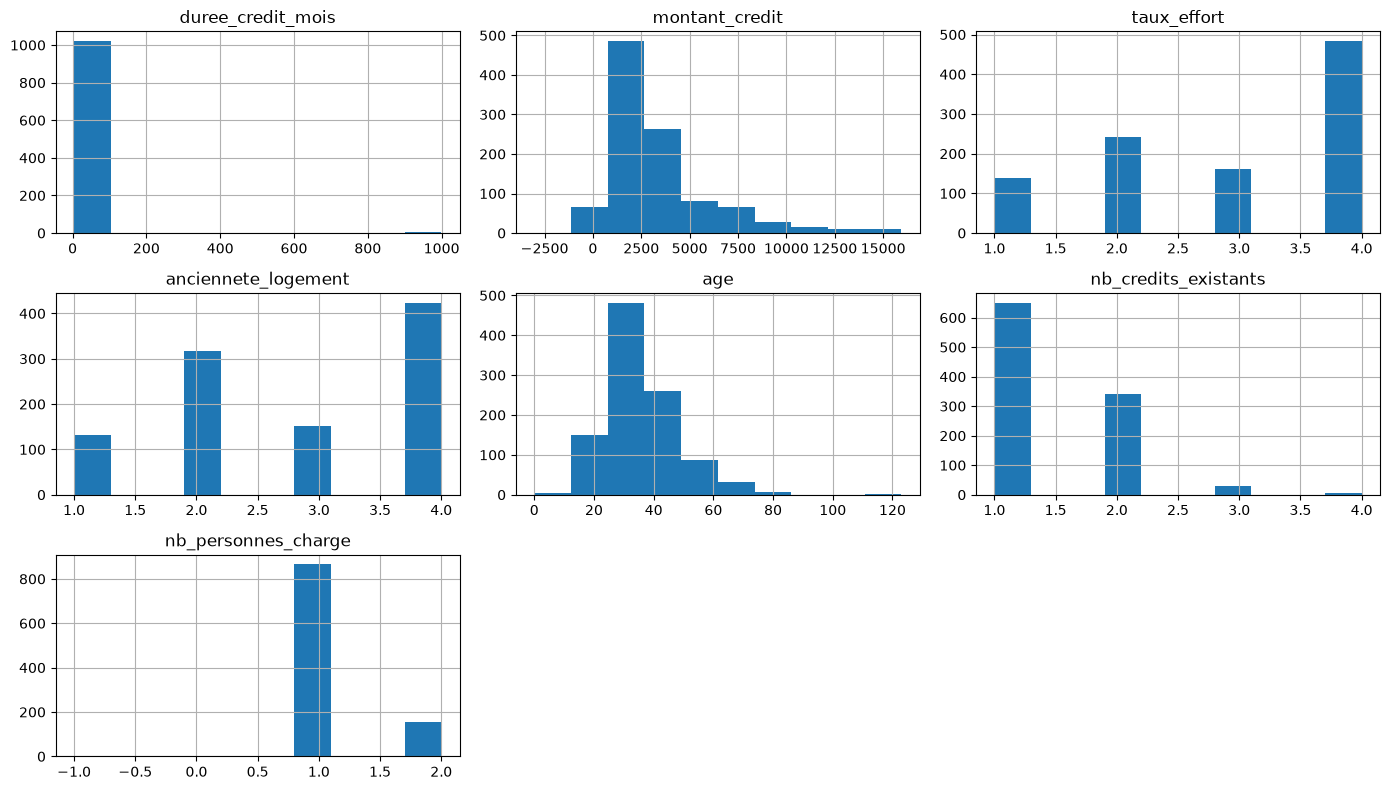

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_num = ['duree_credit_mois', 'montant_credit', 'taux_effort', 
            'anciennete_logement', 'age', 'nb_credits_existants', 'nb_personnes_charge']

df[cols_num].hist(figsize=(14, 8))
plt.tight_layout()
plt.show()

#### Variables catégorielles
Les countplots confirment les incohérences de format détectées :
- `travailleur_etranger` — 5 barres visibles au lieu de 2, 
  preuve des variantes de casse (`oui`, `Oui `, `OUI`, `non`, ` non`)
- `epargne` — présence du NaN comme catégorie distincte 
  de `"pas d'épargne connue"`

> Les visualisations confirment l'état des lieux chiffré et justifient 
> les corrections à apporter dans l'étape 3.

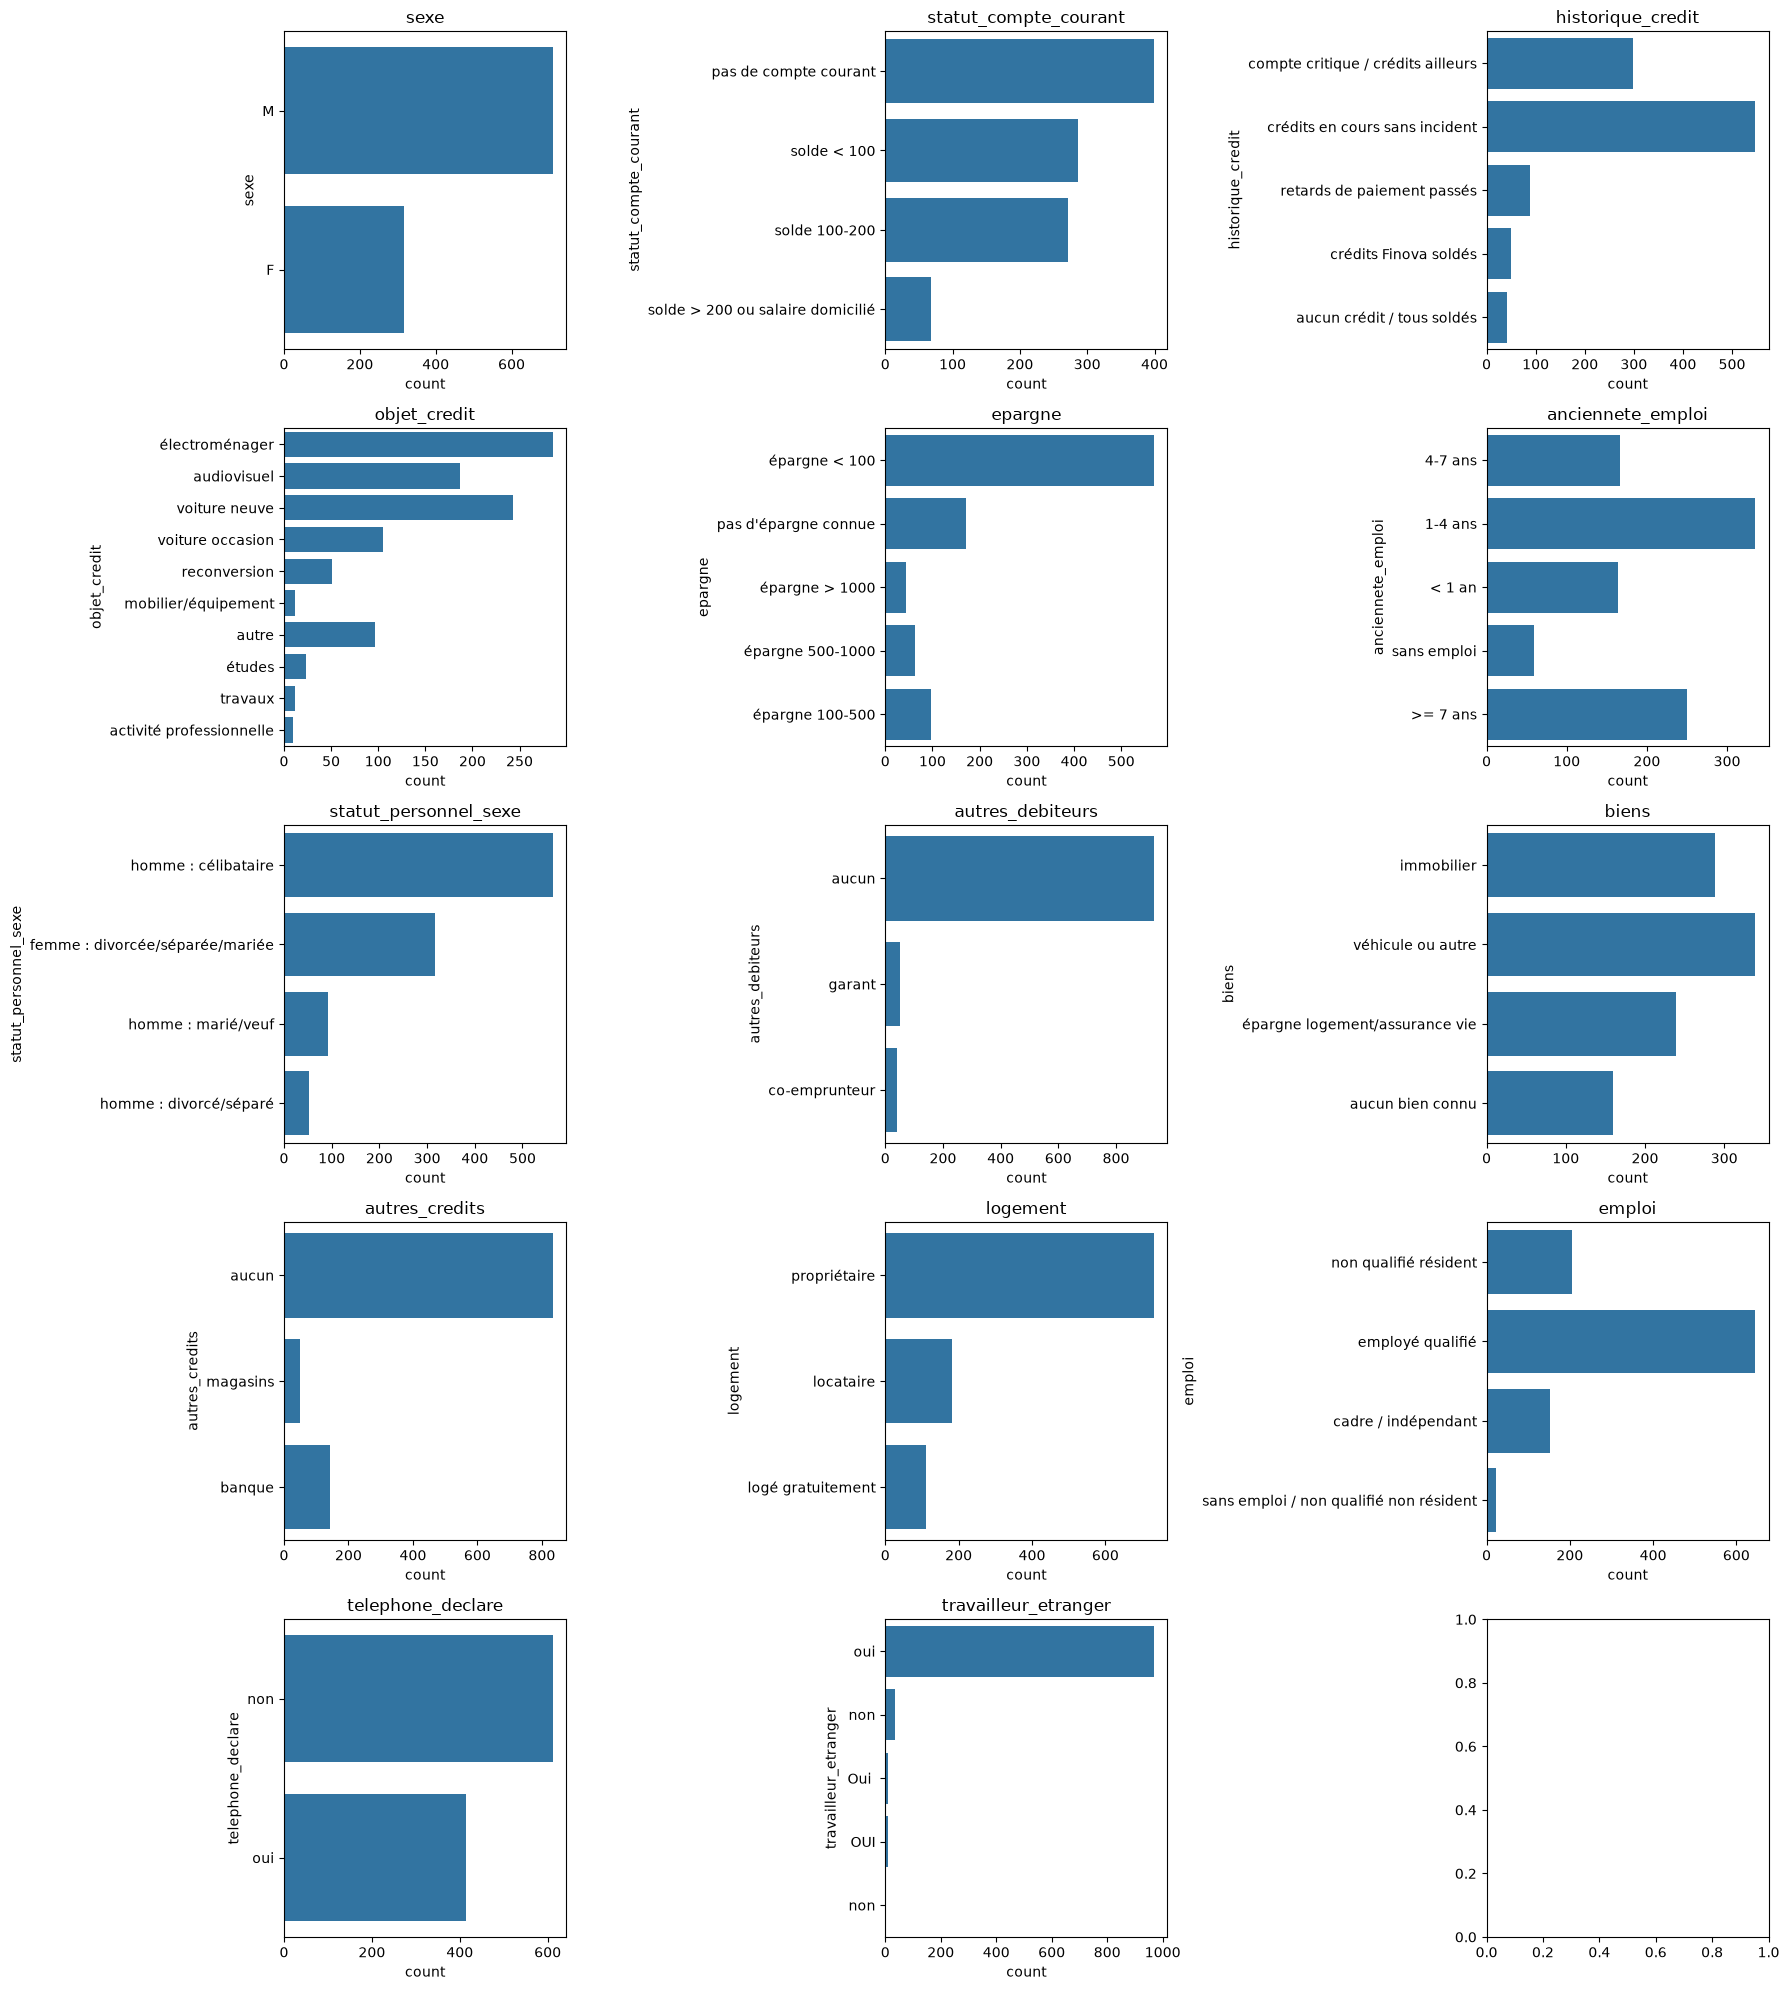

In [17]:
cols_cat = ['sexe', 'statut_compte_courant', 'historique_credit', 'objet_credit', 
            'epargne', 'anciennete_emploi', 'statut_personnel_sexe', 
            'autres_debiteurs', 'biens', 'autres_credits', 'logement', 
            'emploi', 'telephone_declare', 'travailleur_etranger']

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, col in enumerate(cols_cat):
    sns.countplot(data=df, y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Etape 3 : Corrections apportées

## 3.1 Traiter les valeurs manquantes

### 3.1.1. Parsing de `montant_credit` (mis à jour)
- Nettoyage de texte : suppression " EUR", espaces, virgule → point
- **Résultat : 25 valeurs récupérées** (45 NaN → 20 NaN)
- Imputation des 20 NaN restants par la **médiane (2320€)** 
  plutôt que la moyenne — plus robuste aux valeurs extrêmes

>  **Limite connue :** Dans cette version, l'imputation médiane de 
> `montant_credit` est réalisée avant le découpage train/test. 
> Pour une version production entièrement conforme, cette étape 
> devrait être intégrée dans un `Pipeline` sklearn afin que la médiane 
> soit apprise uniquement sur le train et appliquée sur le test.

In [18]:
df = load_data()
df["montant_credit"] = pd.to_numeric(
    df["montant_credit"].str.replace(" EUR", "").str.replace(" ", "").str.replace(",", "."),
    errors="coerce"
)
df["montant_credit"] = df["montant_credit"].fillna(df["montant_credit"].median())
print(f"NaN restants : {df['montant_credit'].isnull().sum()}")
print(f"Médiane utilisée : {df['montant_credit'].median()}")

NaN restants : 0
Médiane utilisée : 2320.0


### 3.1.2. Suppression des doublons
- 18 doublons exacts supprimés via `drop_duplicates()`
- 7 doublons masqués supprimés via `drop_duplicates(subset=[...])`
- **Résultat : 1000 dossiers propres** (vs 897 avant)

In [19]:
df = df.drop_duplicates()
df = df.drop_duplicates(subset=['age', 'sexe', 'code_postal', 'montant_credit', 'duree_credit_mois'])
print(f"Lignes après déduplication masquée : {len(df)}")


Lignes après déduplication masquée : 1000


### 3.1.3 Imputation des valeurs manquantes
Remplacement du `dropna()` par une imputation contextuelle :
- `epargne` → `"pas d'épargne connue"`
- `anciennete_emploi` → `"sans emploi"`
- **0 NaN restants**, aucun dossier supprimé inutilement

In [20]:
df["epargne"] = df["epargne"].fillna("pas d'épargne connue")
df["anciennete_emploi"] = df["anciennete_emploi"].fillna("sans emploi")
print(f"NaN restants : {df.isnull().sum().sum()}")
print(f"epargne : {df['epargne'].unique()}")
print(f"anciennete_emploi : {df['anciennete_emploi'].unique()}")

NaN restants : 0
epargne : <StringArray>
['pas d'épargne connue',        'épargne < 100',       'épargne > 1000',
     'épargne 500-1000',      'épargne 100-500']
Length: 5, dtype: str
anciennete_emploi : <StringArray>
['4-7 ans', '1-4 ans', '< 1 an', 'sans emploi', '>= 7 ans']
Length: 5, dtype: str


### 3.1.4. Normalisation de `travailleur_etranger`
`str.strip().str.lower()` ramène 5 variantes à 2 valeurs propres :
`"oui"` et `"non"`.

In [21]:
df["travailleur_etranger"] = df["travailleur_etranger"].str.strip().str.lower()
print(f"NaN restants : {df.isnull().sum().sum()}")
print(f"travailleur_etranger : {df['travailleur_etranger'].unique()}")

NaN restants : 0
travailleur_etranger : <StringArray>
['oui', 'non']
Length: 2, dtype: str


## 3.2 Traiter les valeurs aberrantes

### 3.2.1 Traitement des valeurs aberrantes — colonne : `age`

4 dossiers avec `age` < 18 et 2 dossiers avec `age` > 100 ont été supprimés.

**Justification :** L'âge est une donnée vitale pour l'évaluation d'un dossier 
de crédit. Un âge impossible (0, 123 ans) remet en question la fiabilité 
de l'ensemble du dossier — on ne peut ni corriger ni imputer une valeur 
qu'on ne connaît pas. Ces 6 lignes (0.6% du dataset) ont donc été supprimées.

In [22]:
df = df[(df['age'] >= 18) & (df['age'] <= 100)]
print(len(df))

994


### 3.2.2 Traitement des valeurs aberrantes — colonne : `montant_credit`

3 dossiers avec un montant de crédit négatif ont été supprimés.

**Justification :** Un montant négatif est une erreur de saisie évidente — 
un crédit ne peut pas avoir un montant négatif. Avec seulement 3 lignes 
concernées (0.3% du dataset), la suppression est la décision la plus simple 
et la plus défendable.

**Note :** Si le nombre de lignes aberrantes avait été significatif, 
une correction par imputation (ex: remplacement par la médiane) aurait 
été envisagée plutôt que de perdre trop de données.

In [23]:
df = df[df['montant_credit'] >= 0]
print(len(df))

991


### 3.2.3 Traitement des valeurs aberrantes — colonnes : `duree_credit_mois` et `nb_personnes_charge`

- 3 dossiers avec `duree_credit_mois` > 120 mois supprimés
- 2 dossiers avec `nb_personnes_charge` < 0 supprimés

**Justification :** Même logique que `montant_credit` — erreurs de saisie 
évidentes, nombre de lignes négligeable, suppression retenue.

In [24]:
df = df[(df['duree_credit_mois'] <= 120) & (df['nb_personnes_charge'] >= 0)]
print(len(df))

986


## 3.3 Revoir l'encodage des variables catégorielles et la normalisation des variables numériques.

### 3.3.1 Encodage ordinal — colonne : `epargne`

Remplacement du `LabelEncoder` par un `OrdinalEncoder` avec un ordre 
métier explicite :

| Valeur | Code |
|--------|------|
| `pas d'épargne connue` | 0 |
| `épargne < 100` | 1 |
| `épargne 100-500` | 2 |
| `épargne 500-1000` | 3 |
| `épargne > 1000` | 4 |

**Justification :** L'ordre reflète la capacité financière du demandeur — 
une information cruciale pour le scoring crédit. Le `LabelEncoder` 
assignait un ordre alphabétique arbitraire qui faussait cette logique.

In [25]:
from sklearn.preprocessing import OrdinalEncoder

ordre_epargne = [["pas d'épargne connue", "épargne < 100", "épargne 100-500", "épargne 500-1000", "épargne > 1000"]]

enc = OrdinalEncoder(categories=ordre_epargne)
df[["epargne"]] = enc.fit_transform(df[["epargne"]])
print(df["epargne"].unique())

[0. 1. 4. 3. 2.]


In [26]:
# Créer un mapping pour vérifier l'encodage
mapping_ordre_epargne = dict(zip(ordre_epargne[0], range(len(ordre_epargne[0]))))
print(mapping_ordre_epargne)

{"pas d'épargne connue": 0, 'épargne < 100': 1, 'épargne 100-500': 2, 'épargne 500-1000': 3, 'épargne > 1000': 4}


### 3.3.2 Encodage ordinal les autres colonnes — `statut_compte_courant`, `historique_credit`, `anciennete_emploi`, `emploi`

Même approche que pour `epargne` — remplacement du `LabelEncoder` 
par un `OrdinalEncoder` avec un ordre métier explicite pour chaque colonne.

| Colonne | Logique d'ordre |
|---------|----------------|
| `statut_compte_courant` | Du moins au plus favorable (pas de compte → solde élevé) |
| `historique_credit` | Du plus au moins risqué (compte critique → aucun crédit) |
| `anciennete_emploi` | Du moins au plus stable (sans emploi → >= 7 ans) |
| `emploi` | Du moins au plus qualifié (sans emploi → cadre) |

In [27]:
# Encodage ordinal statut_compte_courant 
ordre_statut_compte = [["pas de compte courant", "solde < 100", "solde 100-200", "solde > 200 ou salaire domicilié"]]

enc = OrdinalEncoder(categories=ordre_statut_compte)
df[["statut_compte_courant"]] = enc.fit_transform(df[["statut_compte_courant"]])
mapping_ordre_stutut_compte = dict(zip(ordre_statut_compte[0], range(len(ordre_statut_compte[0]))))
print(mapping_ordre_stutut_compte)

# Encodage ordinal historique_credit
ordre_historique = [["compte critique / crédits ailleurs", "retards de paiement passés", 
                     "crédits en cours sans incident", "crédits Finova soldés", 
                     "aucun crédit / tous soldés"]]
enc = OrdinalEncoder(categories=ordre_historique)
df[["historique_credit"]] = enc.fit_transform(df[["historique_credit"]])
mapping_ordre_historique = dict(zip(ordre_historique[0], range(len(ordre_historique[0]))))
print(mapping_ordre_historique)

# Encodage ordinal anciennete_emploi
ordre_anciennete = [["sans emploi", "< 1 an", "1-4 ans", "4-7 ans", ">= 7 ans"]]
enc = OrdinalEncoder(categories=ordre_anciennete)
df[["anciennete_emploi"]] = enc.fit_transform(df[["anciennete_emploi"]])
mapping_ordre_anciennete = dict(zip(ordre_anciennete[0], range(len(ordre_anciennete[0]))))
print(mapping_ordre_anciennete)

# Encodage ordinal emploi
ordre_emploi = [["sans emploi / non qualifié non résident", "non qualifié résident", 
                 "employé qualifié", "cadre / indépendant"]]
enc = OrdinalEncoder(categories=ordre_emploi)
df[["emploi"]] = enc.fit_transform(df[["emploi"]])
mapping_ordre_emploi = dict(zip(ordre_emploi[0], range(len(ordre_emploi[0]))))
print(mapping_ordre_emploi)

{'pas de compte courant': 0, 'solde < 100': 1, 'solde 100-200': 2, 'solde > 200 ou salaire domicilié': 3}
{'compte critique / crédits ailleurs': 0, 'retards de paiement passés': 1, 'crédits en cours sans incident': 2, 'crédits Finova soldés': 3, 'aucun crédit / tous soldés': 4}
{'sans emploi': 0, '< 1 an': 1, '1-4 ans': 2, '4-7 ans': 3, '>= 7 ans': 4}
{'sans emploi / non qualifié non résident': 0, 'non qualifié résident': 1, 'employé qualifié': 2, 'cadre / indépendant': 3}


### 3.3.3 Encodage One-Hot — variables nominales

Remplacement du `LabelEncoder` par `pd.get_dummies()` pour les colonnes 
sans ordre naturel. Chaque catégorie devient une colonne binaire (0 ou 1).

Colonnes encodées : `sexe`, `objet_credit`, `statut_personnel_sexe`, 
`autres_debiteurs`, `biens`, `autres_credits`, `logement`, 
`telephone_declare`, `travailleur_etranger`

**Résultat : 23 colonnes → 48 colonnes**

**Justification :** Le `LabelEncoder` assignait un ordre numérique arbitraire 
à des catégories sans ordre naturel, introduisant un biais dans le modèle. 
Le One-Hot Encoding traite chaque catégorie de façon indépendante.

In [28]:
df = pd.get_dummies(df, columns=["logement", "sexe", "objet_credit", 
                                  "statut_personnel_sexe", "autres_debiteurs", 
                                  "biens", "autres_credits", 
                                  "telephone_declare", "travailleur_etranger"])
print(df.shape)

(986, 48)


In [30]:
print(df.columns.tolist())

['numero_client', 'code_postal', 'statut_compte_courant', 'duree_credit_mois', 'historique_credit', 'montant_credit', 'epargne', 'anciennete_emploi', 'taux_effort', 'anciennete_logement', 'age', 'nb_credits_existants', 'emploi', 'nb_personnes_charge', 'defaut', 'logement_locataire', 'logement_logé gratuitement', 'logement_propriétaire', 'sexe_F', 'sexe_M', 'objet_credit_activité professionnelle', 'objet_credit_audiovisuel', 'objet_credit_autre', 'objet_credit_mobilier/équipement', 'objet_credit_reconversion', 'objet_credit_travaux', 'objet_credit_voiture neuve', 'objet_credit_voiture occasion', 'objet_credit_électroménager', 'objet_credit_études', 'statut_personnel_sexe_femme : divorcée/séparée/mariée', 'statut_personnel_sexe_homme : célibataire', 'statut_personnel_sexe_homme : divorcé/séparé', 'statut_personnel_sexe_homme : marié/veuf', 'autres_debiteurs_aucun', 'autres_debiteurs_co-emprunteur', 'autres_debiteurs_garant', 'biens_aucun bien connu', 'biens_immobilier', 'biens_véhicule o

### 3.3.4 Normalisation des variables numériques — correction du data leakage

**Problème identifié dans le pipeline original :**
Le `StandardScaler` était fitté sur l'ensemble des données AVANT le 
`train_test_split`, introduisant un data leakage — le modèle avait 
une connaissance indirecte du jeu de test pendant l'entraînement.
Cela expliquait les scores anormalement optimistes constatés.

**Corrections apportées :**

1. **Ordre des opérations corrigé**
   - Split d'abord → `train_test_split(X, y, test_size=0.2, random_state=42)`
   - Scaler fitté uniquement sur le train → `scaler.fit_transform(X_train)`
   - Scaler appliqué sur le test → `scaler.transform(X_test)`

2. **Reproductibilité assurée**
   Ajout de `random_state=42` — le découpage est maintenant identique 
   à chaque exécution.

3. **`numero_client` nettoyé**
   Suppression du préfixe `"FIN-"` et conversion en entier avant 
   la normalisation.

**Résultat : Train (788, 47) | Test (198, 47)**

In [34]:
df["numero_client"] = df["numero_client"].str.replace("FIN-", "").astype(int)
def prepare_datasets(df):
    X = df.drop(columns=["defaut"])
    y = df["defaut"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test

In [35]:
X_train, X_test, y_train, y_test = prepare_datasets(df)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (788, 47) | Test : (198, 47)


## Étape 4 : Reconstruction des jeux d'entraînement et de test

### 4.1 Cause des scores anormalement optimistes
Le problème identifié et corrigé en étape 3 était un **data leakage** :
le `StandardScaler` était fitté sur l'ensemble des données avant le split,
donnant au modèle une connaissance indirecte du jeu de test.

### Jeux reconstruits
Les jeux ont été reconstruits après toutes les corrections et exportés :
- `train_v2.csv` — **788 dossiers**
- `test_v2.csv` — **198 dossiers**
- Découpage reproductible : `random_state=42`
- Aucune fuite d'information du test vers le train

In [36]:
cols = df.drop(columns=["defaut"]).columns

X_train_df = pd.DataFrame(X_train, columns=cols)
X_test_df = pd.DataFrame(X_test, columns=cols)

X_train_df.assign(defaut=y_train.values).to_csv("train_v2.csv", index=False)
X_test_df.assign(defaut=y_test.values).to_csv("test_v2.csv", index=False)
print("Exporté : train_v2.csv | test_v2.csv")

Exporté : train_v2.csv | test_v2.csv


### 4.2 Validation du pipeline corrigé

Afin de vérifier l'impact de toutes les corrections apportées, et corriger 
le biais d'analyse observé en étape 1 (accuracy seule insuffisante pour 
un scoring crédit), nous avons souhaité comparer les performances 
avant/après via un `classification_report`.

| Métrique | Pipeline original | Pipeline corrigé |
|----------|-------------------|------------------|
| Accuracy | 0.728 | 0.753 |
| Recall classe 1 (défaut) | non mesuré | 0.42 |

**Interprétation :**
- L'accuracy est légèrement meilleure et désormais honnête
- Le recall de 0.42 sur la classe "défaut" indique que le modèle 
  ne détecte que 42% des vrais défauts — métrique la plus critique 
  pour une banque

In [37]:
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Accuracy : 0.753
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       138
           1       0.64      0.42      0.51        60

    accuracy                           0.75       198
   macro avg       0.71      0.66      0.67       198
weighted avg       0.74      0.75      0.74       198



**Recommandation :**
Dans la vraie vie, on chercherait à améliorer ces résultats en testant 
d'autres classificateurs (Random Forest, SVC) et en appliquant un 
`class_weight='balanced'` pour traiter le déséquilibre des classes — 
comme abordé dans le brief 3.

Cependant, l'objectif ici est uniquement de fiabiliser le pipeline de 
préparation des données. Le choix et l'optimisation du modèle constituent 
la prochaine étape, comme demandé par le manager : *"Avant de parler de 
modèle, je veux savoir si on peut faire confiance aux données."*

## Étape 5 : Formater et stocker

### 5.1 Création de la base cible
Les jeux d'entraînement et de test ont été stockés dans une base SQLite 
`finova_credits_clean.db` avec deux tables distinctes :
- `train` — jeu d'entraînement
- `test` — jeu de test

In [38]:
conn = sqlite3.connect("finova_credits_clean.db")

X_train_df.assign(defaut=y_train.values).to_sql("train", conn, if_exists="replace", index=False)
X_test_df.assign(defaut=y_test.values).to_sql("test", conn, if_exists="replace", index=False)

conn.close()
print("Base créée : finova_credits_clean.db")

Base créée : finova_credits_clean.db


### 5.2 Vérification de l'intégrité du chargement

| Table | Lignes |
|-------|--------|
| `train` | 788 |
| `test` | 198 |

**Total : 986 dossiers** — cohérent avec le dataset propre issu 
de toutes les corrections de l'étape 3.

In [39]:
conn = sqlite3.connect("finova_credits_clean.db")
print("Table train :", pd.read_sql("SELECT COUNT(*) FROM train", conn).values[0][0], "lignes")
print("Table test :", pd.read_sql("SELECT COUNT(*) FROM test", conn).values[0][0], "lignes")
conn.close()

Table train : 788 lignes
Table test : 198 lignes


## Étape 6 : Fiabiliser dans le temps — contrôles qualité automatisés

### Principe
Le pipeline est propre aujourd'hui, mais de nouveaux dossiers arrivent 
chaque semaine sans garantie de qualité. Pour éviter de rejouer l'audit 
à chaque lot, on implémente une fonction `validate_data()` qui contrôle 
automatiquement chaque nouveau lot en entrée de pipeline.

Tout lot non conforme est **rejeté** avec un rapport explicite — 
on ne corrige pas, on signale.

**3 niveaux de contrôle :**
1. **Schéma** — toutes les colonnes attendues sont présentes, pas de colonnes inattendues
2. **Format** — chaque colonne numérique a le bon type
3. **Règles métier** — les valeurs sont dans des plages valides (age, montant, durée...)

> Dans le notebook, les 3 vérifications sont présentées séparément 
> pour la lisibilité. Dans le pipeline corrigé, elles sont assemblées 
> en une seule fonction `validate_data()` qui génère un rapport CSV 
> et rejette le lot avec une erreur explicite si des violations sont détectées.

### 6.1.1 Vérification du schéma

On définit `COLONNES_ATTENDUES` comme référence et on compare avec 
les colonnes du lot entrant dans les deux sens :

- **Colonnes manquantes** : `set(COLONNES_ATTENDUES) - set(df.columns)`
- **Colonnes inattendues** : `set(df.columns) - set(COLONNES_ATTENDUES)`

In [44]:
COLONNES_ATTENDUES = ['numero_client', 'sexe', 'code_postal', 'statut_compte_courant',
                      'duree_credit_mois', 'historique_credit', 'objet_credit',
                      'montant_credit', 'epargne', 'anciennete_emploi', 'taux_effort',
                      'statut_personnel_sexe', 'autres_debiteurs', 'anciennete_logement',
                      'biens', 'age', 'autres_credits', 'logement', 'nb_credits_existants',
                      'emploi', 'nb_personnes_charge', 'telephone_declare',
                      'travailleur_etranger', 'defaut']

def validate_data(df):
    rapport = []
    
    cols_manquantes = set(COLONNES_ATTENDUES) - set(df.columns)
    if cols_manquantes:
        rapport.append({
            "numero_client": "N/A",
            "type_probleme": "schéma invalide",
            "colonne": str(cols_manquantes),
            "regle_violee": "colonnes manquantes dans le lot"
        })
    
    cols_en_trop = set(df.columns) - set(COLONNES_ATTENDUES)
    if cols_en_trop:
        rapport.append({
            "numero_client": "N/A",
            "type_probleme": "schéma invalide",
            "colonne": str(cols_en_trop),
            "regle_violee": "colonnes inattendues dans le lot"
        })
        
    return pd.DataFrame(rapport)

#### Test ok - Lot conforme → rapport vide → lot accepté

In [45]:
df_test = load_data()
rapport = validate_data(df_test)
print(rapport)

Empty DataFrame
Columns: []
Index: []


#### Test nok - Lot non conforme → rapport avec la liste des colonnes problématiques

> Dans un contexte bancaire, une colonne inattendue peut signaler 
> un problème de stockage ou une fuite de données sensibles.

In [47]:
df_test["colonne_bizarre"] = 1
rapport = validate_data(df_test)
rapport

,numero_client,type_probleme,colonne,regle_violee
0,N/A,schéma invalide,{'colonne_bizarre'},colonnes inattendues dans le lot


### Règle 2 — Vérification des formats

On définit `TYPES_ATTENDUS` comme référence des types numériques attendus 
pour chaque colonne et on compare avec les types réels du lot entrant.

> Note : La vérification porte uniquement sur les colonnes numériques. 
> Les colonnes texte (`str`, `object`) sont exclues car pandas peut 
> les stocker sous différents formats selon la version — 
> une vérification stricte créerait de faux positifs.

In [48]:
TYPES_ATTENDUS = {
    "duree_credit_mois": "int64",
    "montant_credit": "float64",
    "age": "int64",
    "taux_effort": "int64",
    "nb_personnes_charge": "int64",
    "nb_credits_existants": "int64",
    "anciennete_logement": "int64",
    "defaut": "int64"
}

def validate_formats(df):
    rapport = []
    
    for col, type_attendu in TYPES_ATTENDUS.items():
        if col in df.columns and str(df[col].dtype) != type_attendu:
            rapport.append({
                "numero_client": "N/A",
                "type_probleme": "format invalide",
                "colonne": col,
                "regle_violee": f"type={df[col].dtype} (attendu: {type_attendu})"
            })
        
    return pd.DataFrame(rapport)

#### Test ok - Lot conforme → rapport vide → lot accepté

df_test = load_data()
rapport = validate_data(df_test)
print(rapport)

#### Test nok - Lot non conforme → rapport avec le type reçu vs le type attendu


In [50]:
df_test["age"] = df_test["age"].astype(str)
rapport = validate_formats(df_test)
rapport

,numero_client,type_probleme,colonne,regle_violee
0,N/A,format invalide,montant_credit,type=str (attendu: float64)
1,N/A,format invalide,age,type=str (attendu: int64)


### Règle 3 — Vérification des règles métier

Pour chaque dossier, on vérifie que les valeurs numériques respectent 
les contraintes métier et légales. Chaque violation est reportée avec 
le numéro client, la colonne concernée et la valeur reçue.

| Colonne | Règle | Justification |
|---------|-------|---------------|
| `age` | 18 ≤ age ≤ 100 | Âge légal minimum pour un crédit conso, âge biologiquement plausible |
| `montant_credit` | 0 < montant ≤ 75 000 | Plafond légal crédit conso en France |
| `duree_credit_mois` | 1 ≤ durée ≤ 120 | Durée max crédit conso = 10 ans |
| `nb_personnes_charge` | 0 ≤ nb ≤ 6 | Nombre de personnes à charge plausible |

**Note :** Certaines règles ont été ajoutées de manière proactive, 
notamment les valeurs maximales (`montant_credit` ≤ 75 000, 
`duree_credit_mois` ≤ 120, `nb_personnes_charge` ≤ 6), 
même si elles n'ont pas été détectées dans les données actuelles. 
Elles protègent le pipeline contre de futures anomalies, surtout 
lorsqu'il s'agit de règles légales comme le plafond de 75 000€ 
pour un crédit à la consommation en France.

In [53]:
def validate_data(df):
    rapport = []
    
    # age
    masque = (df["age"] < 18) | (df["age"] > 100)
    for _, row in df[masque].iterrows():
        rapport.append({
            "numero_client": row["numero_client"],
            "type_probleme": "valeur aberrante",
            "colonne": "age",
            "regle_violee": f"age={row['age']} (attendu: 18-100)"
        })

    # montant_credit
    masque = (df["montant_credit"] < 0) | (df["montant_credit"] > 75000)
    for _, row in df[masque].iterrows():
        rapport.append({
            "numero_client": row["numero_client"],
            "type_probleme": "valeur aberrante",
            "colonne": "montant_credit",
            "regle_violee": f"montant_credit={row['montant_credit']} (attendu: 0-75000)"
        })
    #durée_credit_mois
    masque = (df["duree_credit_mois"] <= 0) | (df["duree_credit_mois"] > 120)
    for _, row in df[masque].iterrows():
        rapport.append({
            "numero_client": row["numero_client"],
            "type_probleme": "valeur aberrante",
            "colonne": "duree_credit_mois",
            "regle_violee": f"duree_credit_mois={row['duree_credit_mois']} (attendu: 1-120)"
        })

    #nb_personnes_charges
    masque = (df["nb_personnes_charge"] < 0) | (df["nb_personnes_charge"] > 6)
    for _, row in df[masque].iterrows():
        rapport.append({
            "numero_client": row["numero_client"],
            "type_probleme": "valeur aberrante",
            "colonne": "nb_personnes_charge",
            "regle_violee": f"nb_personnes_charge={row['nb_personnes_charge']} (attendu: 0-6)"
        })
    
    return pd.DataFrame(rapport)

**Test sur les données brutes Finova : 14 violations détectées**
— cohérent avec l'audit de l'étape 2.

In [56]:
df_test = load_data()
df_test["montant_credit"] = pd.to_numeric(
    df_test["montant_credit"].str.replace(" EUR", "").str.replace(" ", "").str.replace(",", "."),
    errors="coerce"
)
rapport = validate_data(df_test)
rapport

,numero_client,type_probleme,colonne,regle_violee
0,FIN-100643,valeur aberrante,age,age=123 (attendu: 18-100)
1,FIN-100926,valeur aberrante,age,age=0 (attendu: 18-100)
2,FIN-100876,valeur aberrante,age,age=0 (attendu: 18-100)
3,FIN-100829,valeur aberrante,age,age=0 (attendu: 18-100)
4,FIN-100789,valeur aberrante,age,age=123 (attendu: 18-100)
5,FIN-100098,valeur aberrante,age,age=0 (attendu: 18-100)
6,FIN-100102,valeur aberrante,montant_credit,montant_credit=-932.0 (attendu: 0-75000)
7,FIN-100194,valeur aberrante,montant_credit,montant_credit=-3031.0 (attendu: 0-75000)
8,FIN-100472,valeur aberrante,montant_credit,montant_credit=-654.0 (attendu: 0-75000)
9,FIN-100558,valeur aberrante,duree_credit_mois,duree_credit_mois=999 (attendu: 1-120)
